# 02 — Stage 1 Validation

**Three claims, three pieces of evidence — *with the training that produces them***.

NB02 trains all 6 variants and runs the eval suite. Re-running NB02 picks up
from the latest checkpoint per variant (no lost hours). Eval cells (§2–§5)
load the latest checkpoint from disk, so they can be re-run independently
once training has produced *something* to evaluate.

| | |
|---|---|
| Reading time | ~10 min (full evidence) |
| Run time     | **smoke**: ~25 min (6 variants × 1k steps)<br>**full**: ~3 h (6 variants × 60k steps), one-shot |
| Trains       | ✅ — full training pipeline lives here |
| Resource dir | `notebook/02_resources/` |
| Linked       | vision doc §9.1.ter / §9.2 ; `note/triangle_sanity_check.md` |

## Stage 1 v1 protocol (synthetic for TEST only)

- **train**: AMASS canonical (5066 clips, 4.22 h)
- **K-eval**: Kimodo OOD test (2000 clips, 1.67 h, balanced families)
- **A-eval**: AMASS heldout ∩ labeled (264 clips, 0.22 h, realism check)
- **A-other-eval**: AMASS heldout ∩ "other" (354 clips, 0.29 h, hardest)

## Three claims

1. **Reconstruction baseline** — variants reach comparable MPJPE.
   Headline: `full ≈ opm_only` on A-eval. Numbers reported per-family
   (macro-averaged) to neutralize walk-bias in eval set.
2. **Triangle is a representation geometry selector, not a loss optimizer**
   *(publishable headline)* — `full` and `opm_only` have ≈ same loss but
   only `full` produces modular pair geometry.
3. **Motor damage robustness** — under joint-mask damage, modular-pair models
   degrade more gracefully. Uses `joint` mask, NOT `kinematic_chain`.

## Required `02_resources/scripts/` modules (NEXT to implement)

```
train_runner.py        # train_variant(name, ...) → ckpt + loss curve
eval_recon.py          # mpjpe_eval(ckpt, subset) → per-family MPJPE table
eval_pair_geometry.py  # pair_heatmap, modularity_score, pair_pca
eval_damage.py         # joint_mask_sweep(ckpt, subset, ks=[0,1,2,3])
eval_style_emerg.py    # extract_pair_embeddings, cluster_and_compare_to_labels
viz_eval.py            # heatmap, sweep curves, worst-K gallery
```

> Each module's signature is sketched in the cells below as type hints + TODO.
> `synergy.py` already exists (legacy from experiment/eval.py — kept as
> reference, not used in main eval).


## §0 Bootstrap + axis/coord sanity


In [1]:
# §0.1 sys.path setup — make 01_ scripts (data, model) AND 02_ scripts (eval) importable
import sys
from pathlib import Path
from IPython.display import Image, display
import matplotlib.pyplot as plt

REPO_ROOT = Path.cwd().parent
RESOURCES = Path("02_resources")
sys.path.insert(0, str(Path("01_resources/scripts")))   # NB1's algorithm code (model, data, viz)
sys.path.insert(0, str(RESOURCES / "scripts"))          # NB2's eval code

def show_and_save(fig, path):
    """NB-wide pattern: savefig + close + display from disk."""
    path = Path(path); path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(path, dpi=120, bbox_inches="tight", facecolor="white")
    plt.close(fig)
    display(Image(filename=str(path)))


In [2]:
# §0.2 Load shared config from NB1 (single source of truth)
import json
NB1_CFG = Path("01_resources/configs")
ENV           = json.loads((NB1_CFG / "env.json").read_text())
DATA          = json.loads((NB1_CFG / "data.json").read_text())
TRAIN_DEFAULT = json.loads((NB1_CFG / "train_default.json").read_text())
VARIANTS      = json.loads((NB1_CFG / "variants.json").read_text())
print(f"loaded config from {NB1_CFG}/  variants={list(VARIANTS.keys())}")


loaded config from 01_resources/configs/  variants=['full', 'opm_only', 'triangle_only', 'pair_static', 'axial_only', 'baseline']


In [3]:
# §0.3 Reproducibility header
import sys, subprocess, random
import numpy as np, torch

random.seed(ENV["seed"]); np.random.seed(ENV["seed"]); torch.manual_seed(ENV["seed"])
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(ENV["seed"])

print("torch    :", torch.__version__, "| cuda available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("device   :", torch.cuda.get_device_name(0))
print("commit   :", subprocess.check_output(
    ["git", "-C", str(REPO_ROOT), "rev-parse", "--short", "HEAD"]).decode().strip())


torch    : 2.9.1+cu128 | cuda available: True
device   : NVIDIA RTX PRO 6000 Blackwell Workstation Edition
commit   : 4a6684c


### §0.4 Axis / coordinate consistency assertion

This is the **first** thing that runs after config load — verified end-to-end
that FK(local_rot, root) reproduces `joints_world` exactly. If this assertion
fails, do NOT train: data normalization or skeleton convention is broken
upstream and any training run wastes GPU hours.


In [4]:
# §0.4 Axis sanity — 5 lines, ~0.5s. Should print "AXIS OK".
from dataset import MixedMotionDataset
from soma_skeleton import forward_kinematics_torch
import numpy as np, torch

ds = MixedMotionDataset(DATA["amass"]["npz"])
i = 100   # arbitrary
rotmat   = ds.rotmat_tensor[i].unsqueeze(0)
root_un  = torch.from_numpy(ds.root_raw[i]).float().unsqueeze(0)
parents  = torch.from_numpy(ds.parents)
bone_off = torch.from_numpy(ds.bone_offsets).float()

with torch.no_grad():
    fk_pos, _ = forward_kinematics_torch(rotmat, root_un, bone_off, parents)

gt_pos = torch.from_numpy(ds.raw[i])
err = (fk_pos.squeeze(0) - gt_pos).abs().max().item()
assert err < 1e-5, f"AXIS BROKEN — FK mismatch={err:.6f}; do NOT train, fix data first"
print(f"✓ AXIS OK   (max FK error = {err:.6e})")


✓ AXIS OK   (max FK error = 4.172325e-07)


## §1 Training

Training does **not run from this notebook**. It's launched from the CLI:

```bash
# In a terminal at notebook/ (project root):
python 02_resources/scripts/train_all.py --mode smoke      # ~10 min, 6 var × 1k steps
python 02_resources/scripts/train_all.py --mode headline   # ~6  h,  4 var × 30k steps
python 02_resources/scripts/train_all.py --mode full       # ~19 h,  6 var × 60k steps

# In another terminal — live progress with sparkline:
python 02_resources/scripts/monitor.py

# In a third terminal — tensorboard cross-variant overlay:
tensorboard --logdir 02_resources/tensorboard/
```

`train_all.py` queues variants 3-at-a-time on this GPU (empirical safe ceiling),
auto-retries OOM failures once GPU clears. Each `train_runner.py` subprocess
writes `loss_history.json` (paper-grade, every 50 steps) + TB events + atomic
status snapshots to `02_resources/checkpoints/<variant>/`.

**Robustness in `train_runner.py`:**
- Resume from `latest.pt` (re-running a mode picks up where it left off)
- SIGINT → save → exit cleanly
- OOM → halve batch + double grad_accum, capped at 5 retries then `failed_oom`
- FP16 autocast + GradScaler (Blackwell-compatible, ~1.5× faster than FP32)

This notebook only **reads** the artifacts that training wrote to disk.


In [5]:
# §1.1 Load post-training status of each variant
import json
CKPT_ROOT = RESOURCES / "checkpoints"
results = {}
for v in VARIANTS:
    sp = CKPT_ROOT / v / "status.json"
    if sp.exists():
        results[v] = json.loads(sp.read_text())
    else:
        results[v] = {"status": "missing"}

import pandas as pd
pd.DataFrame({v: {
    "status":     d.get("status", "?"),
    "step":       d.get("step", "-"),
    "n_steps":    d.get("n_steps", "-"),
    "loss_recent": d.get("loss_recent", None),
    "ckpt_path":  d.get("ckpt_path", "-"),
} for v, d in results.items()}).T


,status,step,n_steps,loss_recent,ckpt_path
full,done,1000,1000,2.342519,"/home/arenalabs/Desktop/""be water, robot""/note..."
opm_only,done,1000,1000,2.343282,"/home/arenalabs/Desktop/""be water, robot""/note..."
triangle_only,done,1000,1000,2.290069,"/home/arenalabs/Desktop/""be water, robot""/note..."
pair_static,done,1000,1000,2.305997,"/home/arenalabs/Desktop/""be water, robot""/note..."
axial_only,done,1000,1000,2.611595,"/home/arenalabs/Desktop/""be water, robot""/note..."
baseline,done,1000,1000,4.176368,"/home/arenalabs/Desktop/""be water, robot""/note..."


plotting 6 healthy variants: ['full', 'opm_only', 'triangle_only', 'pair_static', 'axial_only', 'baseline']


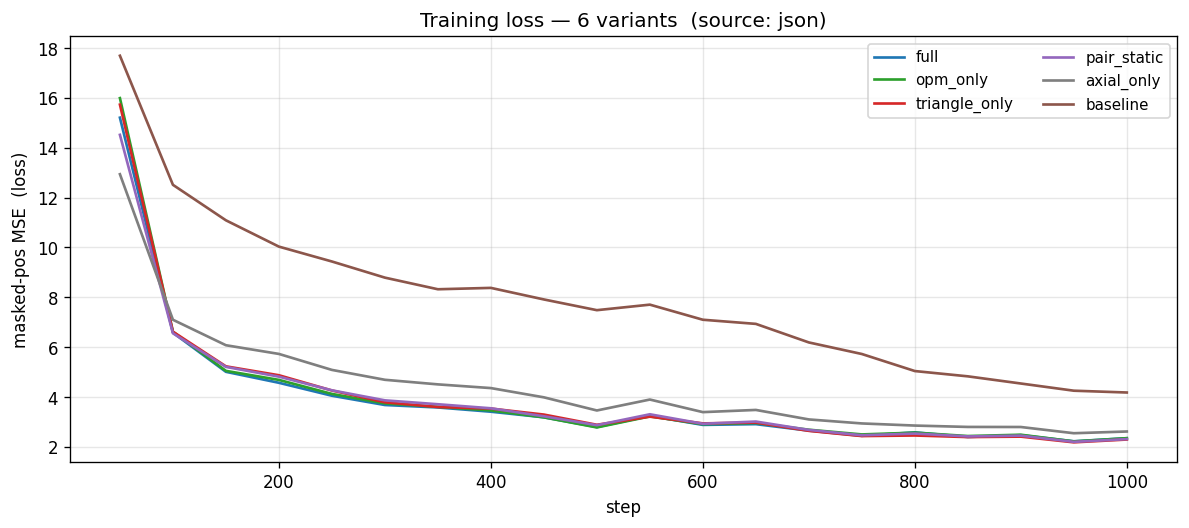

In [6]:
# §1.2 Loss curves — overlay all variants (reads loss_history.json — paper-grade)
from viz_eval import plot_train_loss_overlay_from_tb

healthy = [v for v, d in results.items() if d.get("status") == "done"]
print(f"plotting {len(healthy)} healthy variants: {healthy}")

fig = plot_train_loss_overlay_from_tb(CKPT_ROOT, healthy, source="json")
show_and_save(fig, RESOURCES / "figures/02__train_loss_overlay.png")


## §2 Claim 1 — Reconstruction baseline (3 test sets, per-family)

> Each variant reaches comparable MPJPE on the *real* eval set (A-eval).
> Numbers are reported **per-family then macro-averaged** to neutralize
> walk-bias in the labeled subset.
>
> **K-A gap monitor** (overfit detector): if K-eval ↓ but A-eval ↑ across
> training, the model is overfitting to synthetic distribution. Stage 1 v1
> shouldn't have this since synthetic is held out — but we monitor anyway.


In [7]:
# §2.1 MPJPE per variant on 3 test sets
#
# IMPLEMENTATION (eval_recon.py):
#   def mpjpe_eval(
#       ckpt_path: Path,
#       subset,
#       *, batch_size: int=32, device: str='cuda',
#   ) -> dict:
#       # returns {variant, n, mpjpe_overall, mpjpe_per_joint[J], mpjpe_per_family{f:val}}
#
#   def macro_mpjpe(per_family: dict) -> float:
#       # equal-weight average over families with n>=10
import pandas as pd
from data_loader import (
    load_kimodo_ood, load_amass_heldout_labeled, load_amass_heldout_other,
)
from eval_recon import mpjpe_eval, macro_mpjpe   # TODO

test_sets = {
    "K-eval"        : load_kimodo_ood(DATA),
    "A-eval"        : load_amass_heldout_labeled(DATA),
    "A-other-eval"  : load_amass_heldout_other(DATA),
}

mpjpe_table = {}
for vname in VARIANTS:
    if results.get(vname, {}).get("status") != "done":
        continue
    mpjpe_table[vname] = {
        ts: mpjpe_eval(results[vname]["ckpt_path"], sub)
        for ts, sub in test_sets.items()
    }

# Display: rows = variants, columns = (test_set, mpjpe_overall, mpjpe_macro)
df = pd.DataFrame({
    v: {f"{ts}/overall": d["mpjpe_overall"] for ts, d in vd.items()}
    for v, vd in mpjpe_table.items()
}).T
df


/home/arenalabs/miniconda3/envs/rot/lib/python3.12/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


,K-eval/overall,A-eval/overall,A-other-eval/overall
full,0.029560,0.020085,0.020455
opm_only,0.029603,0.020200,0.020755
triangle_only,0.031021,0.022966,0.023667
pair_static,0.030377,0.021567,0.022078
axial_only,0.030803,0.022977,0.023366
baseline,0.044654,0.038326,0.038645


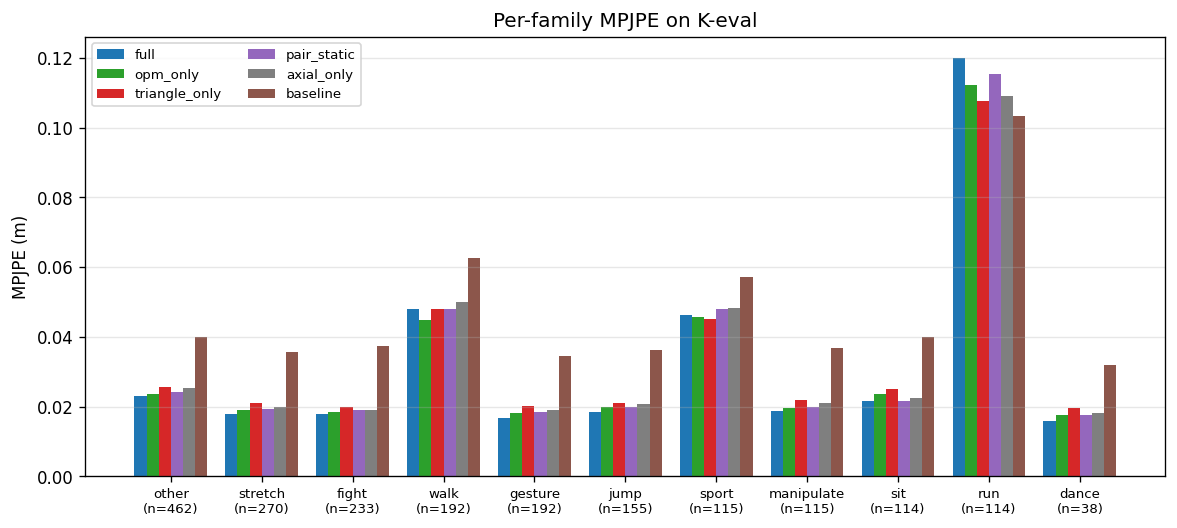

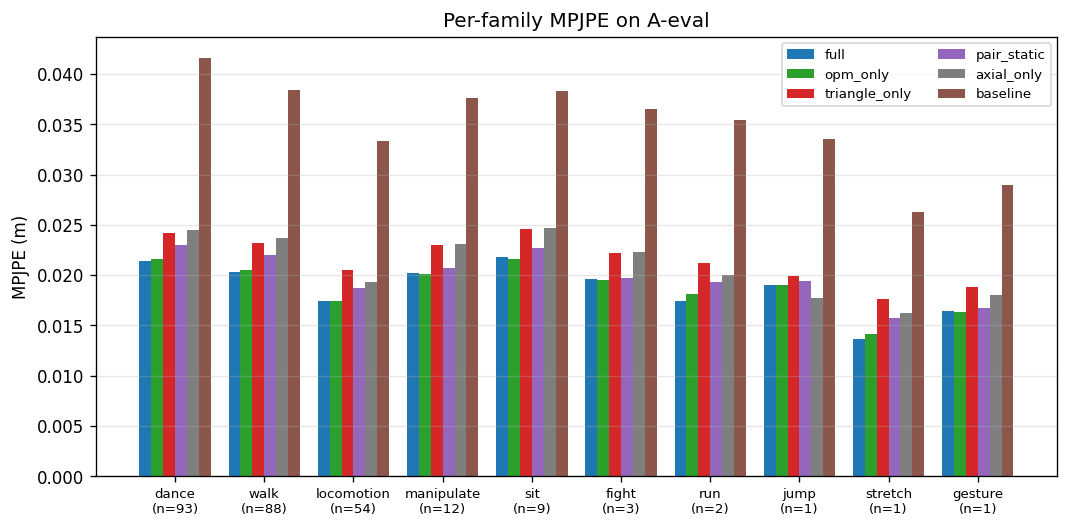

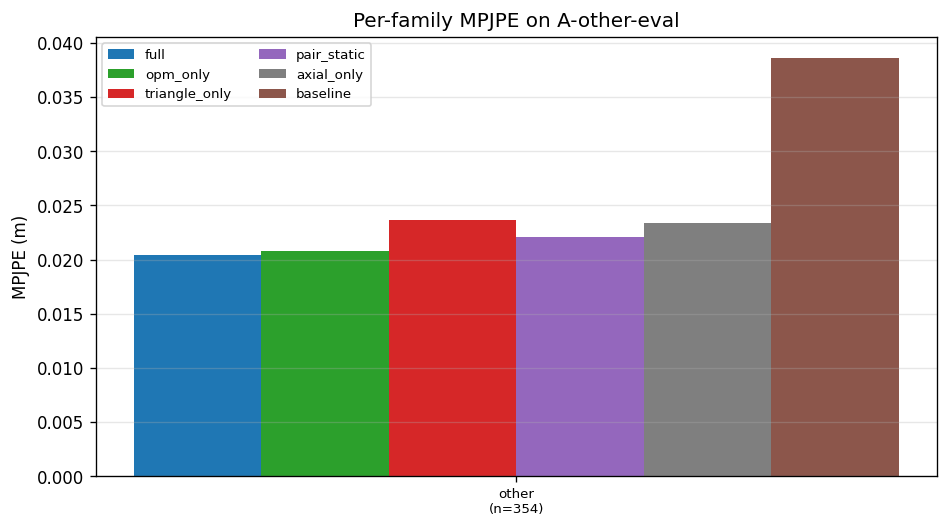

In [8]:
# §2.2 Per-family MPJPE table — exposes walk-bias
# IMPLEMENTATION (viz_eval.py):
#   def plot_per_family_mpjpe(mpjpe_table: dict, test_set: str='A-eval') -> Figure
from viz_eval import plot_per_family_mpjpe   # TODO

for ts in test_sets:
    fig = plot_per_family_mpjpe(mpjpe_table, test_set=ts)
    show_and_save(fig, RESOURCES / f"figures/02__per_family_mpjpe_{ts}.png")


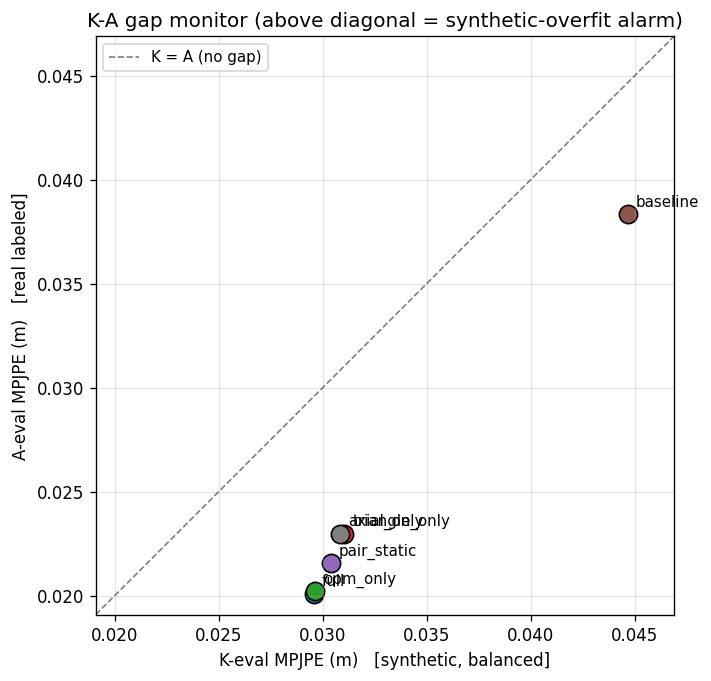

In [9]:
# §2.3 K-A gap monitor (overfit alarm)
# IMPLEMENTATION (viz_eval.py):
#   def plot_k_vs_a_gap(mpjpe_table: dict) -> Figure
#       # x = K-eval MPJPE, y = A-eval MPJPE, one point per variant
#       # diagonal line; points far below = generalize from K to A;
#       # points far above = overfit synthetic
from viz_eval import plot_k_vs_a_gap   # TODO

fig = plot_k_vs_a_gap(mpjpe_table)
show_and_save(fig, RESOURCES / "figures/02__k_vs_a_gap.png")


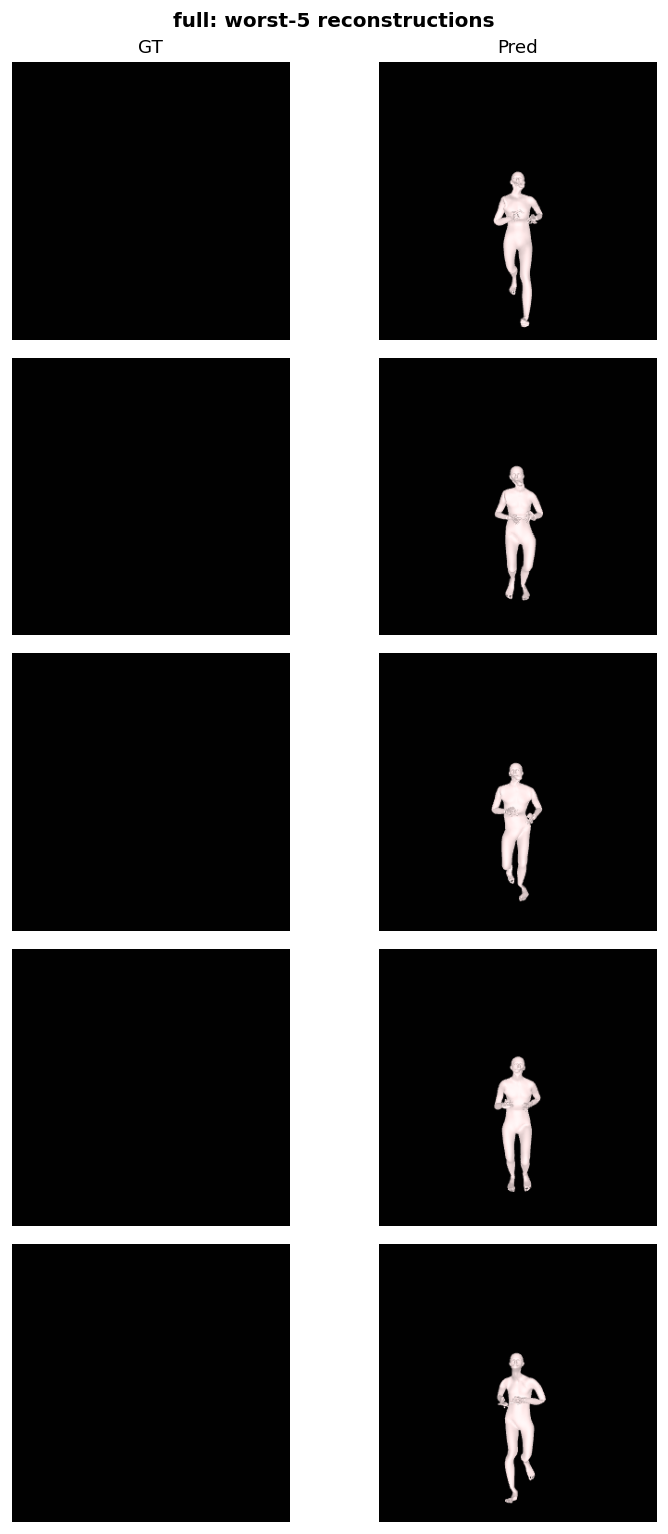

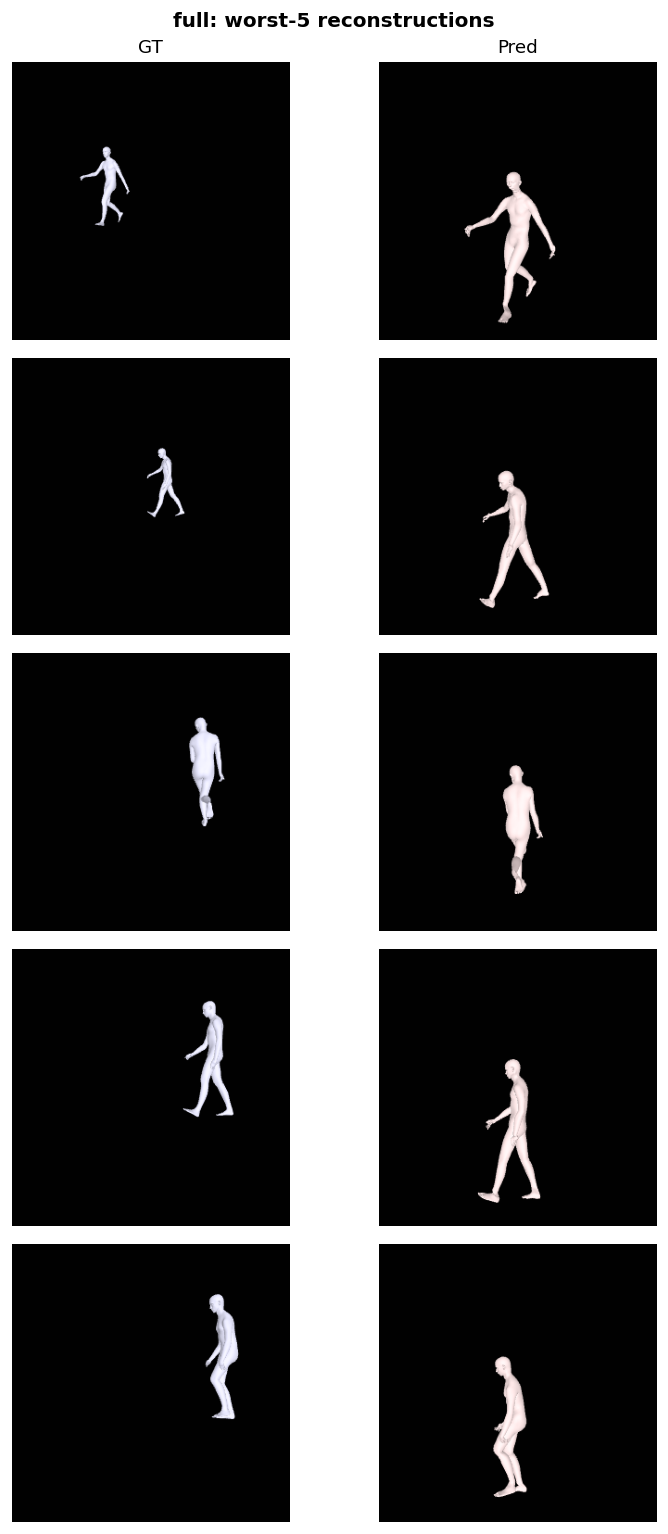

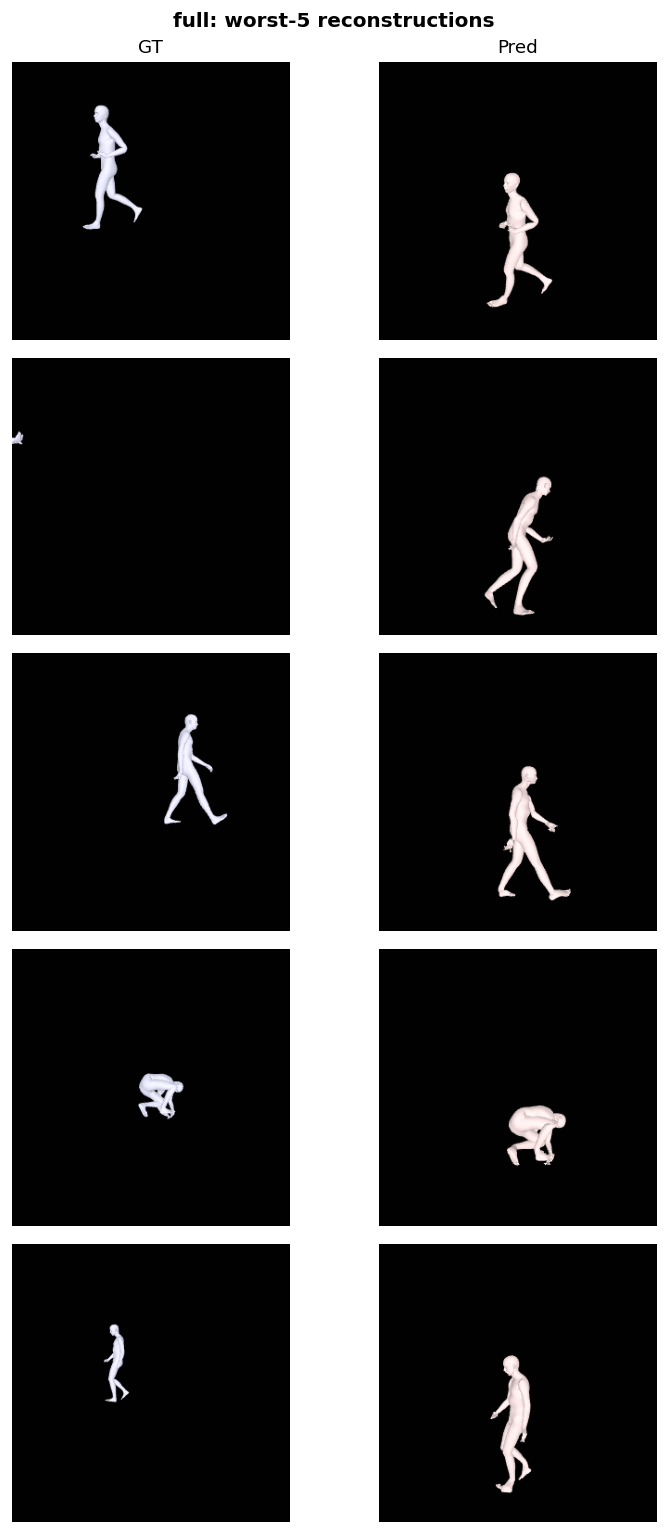

In [10]:
# §2.4 Worst-5 reconstruction failures (one variant, per test set)
# IMPLEMENTATION (viz_eval.py):
#   def worst_k_gallery(ckpt_path, subset, *, k=5, render_meshes=True) -> Figure
#       # Uses lbs.py + mesh_render.py from 01_resources to render side-by-side
#       # gt mesh vs predicted mesh for the K worst clips
from viz_eval import worst_k_gallery   # TODO

best_variant = "full"
for ts, sub in test_sets.items():
    fig = worst_k_gallery(results[best_variant]["ckpt_path"], sub, k=5)
    show_and_save(fig, RESOURCES / f"figures/02__worst5_{best_variant}_{ts}.png")


### §2.5 Interpretation
`full ≈ opm_only` on A-eval reconstruction → **triangle does not contribute
to reconstruction**. Sets up Claim 2: triangle's contribution is in
**representation geometry**, not loss.

Gap to baseline (no pair tensor at all = `axial_only`) shows the *pair-tensor
mechanism* is what matters — not specifically the triangle refinement on top.


### §2.6 Reconstruction GIFs (visual: GT + 6 variants on one walking clip)

For each ckpt: FM 1-step denoise from t=0.95 → un-normalize → FK on predicted
local rotations → LBS skinning → mesh GIF. GT is rendered from the dataset's
`global_rot_mats` + `joints_world` (no model involved).


clip 1102: 0027_circle_walk_poses  (action=walk)
  ✓ GT  → gt.gif
  ✓ full           → full.gif
  ✓ opm_only       → opm_only.gif
  ✓ triangle_only  → triangle_only.gif
  ✓ pair_static    → pair_static.gif
  ✓ axial_only     → axial_only.gif


/home/arenalabs/miniconda3/envs/rot/lib/python3.12/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


  ✓ baseline       → baseline.gif

--- gt.gif ---


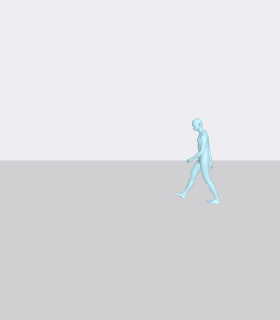


--- full.gif ---


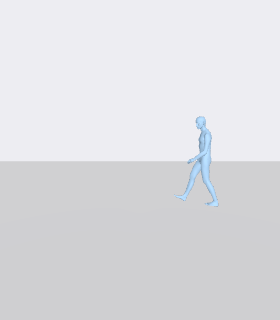


--- opm_only.gif ---


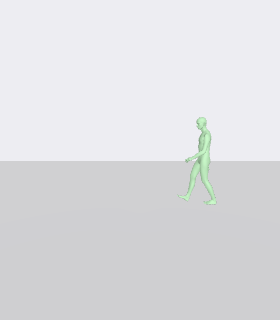


--- triangle_only.gif ---


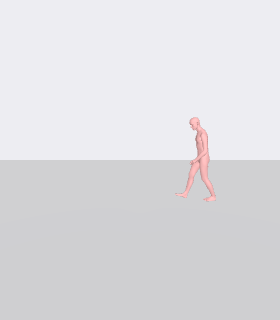


--- pair_static.gif ---


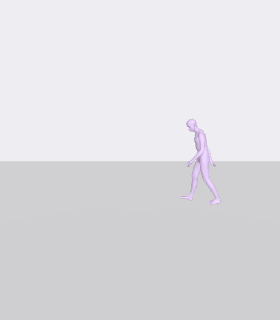


--- axial_only.gif ---


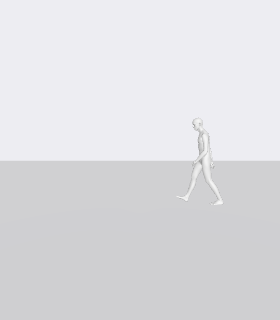


--- baseline.gif ---


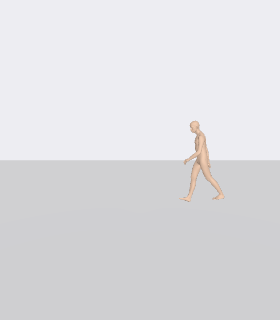

In [11]:
# §2.6 Render reconstruction GIFs — GT + 6 variants
from recon_gif import render_recon_gif_all

# Pick a representative AMASS walking clip from A-eval (heldout ∩ labeled)
ae = test_sets["A-eval"]
walk_pool = [i for i in ae.indices if str(ae.dataset.action_label[i]) == "walk"]
pick = walk_pool[0] if walk_pool else ae.indices[0]
print(f"clip {pick}: {ae.dataset.sample_name[pick]}  "
      f"(action={ae.dataset.action_label[pick]})")

gif_dir = RESOURCES / "figures/recon_gifs"
ckpt_paths = {v: CKPT_ROOT / v / "latest.pt" for v in VARIANTS
              if (CKPT_ROOT / v / "latest.pt").exists()}
written = render_recon_gif_all(int(pick), gif_dir, ckpt_paths,
                                stride=3, fps=10, viewport=(280, 320))

for p in written:
    print(f"\n--- {p.name} ---")
    display(Image(filename=str(p)))


## §3 Claim 2 — Triangle is a representation geometry selector *(publishable headline)*

> `opm_only` learns a **distributed** pair structure.
> Adding the triangle refiner produces **modular** pair structure:
> spine dark-cluster + 4-limb clusters + L/R-Hand hubs.
> Same loss, different geometry — triangle is a **selector** among
> loss-equivalent solutions, not a loss optimizer.
>
> This is the section that becomes the paper's main figure.


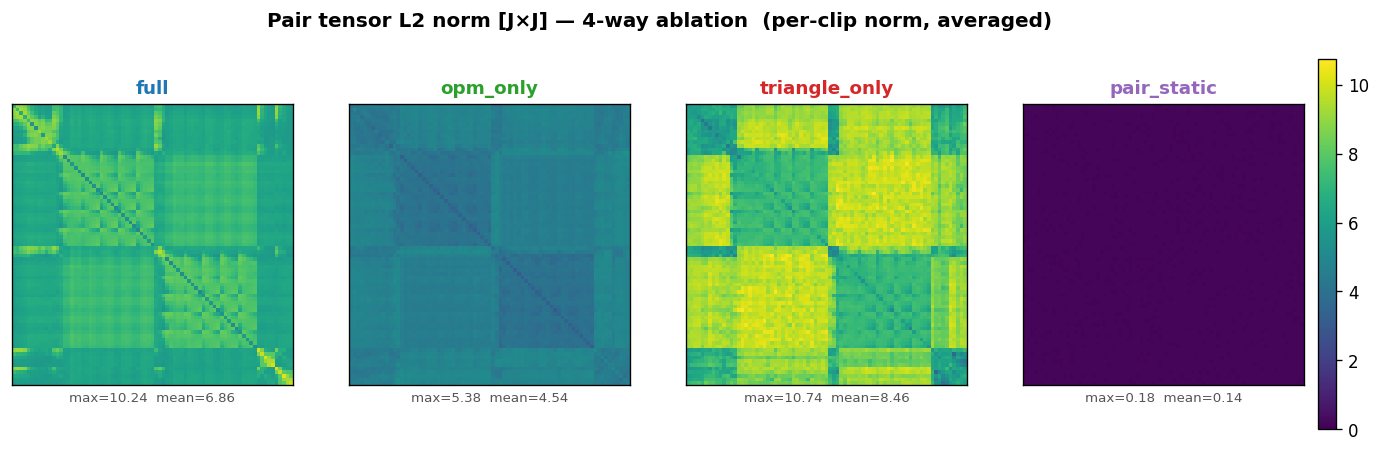

In [12]:
# §3.1 4-way pair heatmap — full / opm_only / triangle_only / pair_static
#
# IMPLEMENTATION (eval_pair_geometry.py):
#   def extract_pair_tensor(ckpt_path, eval_subset, *, n_clips=200) -> np.ndarray:
#       # Forward eval clips, average pair tensor over (B, T) → [J, J]
#       # Returns the mean affinity matrix for that variant.
from eval_pair_geometry import extract_pair_tensor   # TODO
from viz_eval import plot_pair_heatmap_4way            # TODO

ablation_set = ["full", "opm_only", "triangle_only", "pair_static"]
heatmaps = {
    v: extract_pair_tensor(results[v]["ckpt_path"], test_sets["A-eval"], n_clips=200)
    for v in ablation_set
}
fig = plot_pair_heatmap_4way(heatmaps)
show_and_save(fig, RESOURCES / "figures/02__pair_heatmap_4way.png")


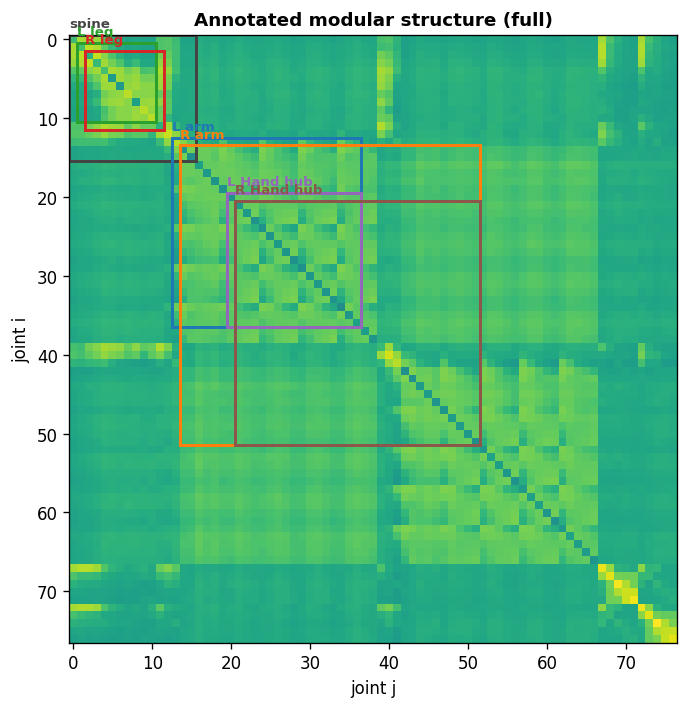

In [13]:
# §3.2 Annotate modular structure on the `full` heatmap
# IMPLEMENTATION (viz_eval.py):
#   def annotate_modular_structure(heatmap, joint_groups) -> Figure
#       # Overlay rectangles for spine block, 4 limb clusters, L/R Hand hubs
from viz_eval import annotate_modular_structure   # TODO

fig = annotate_modular_structure(heatmaps["full"])
show_and_save(fig, RESOURCES / "figures/02__pair_heatmap_full_annotated.png")


In [14]:
# §3.3 Quantitative modularity metric
# IMPLEMENTATION (eval_pair_geometry.py):
#   def modularity_score(heatmap: np.ndarray) -> dict:
#       # returns {silhouette, modularity_coef, hub_score}
import pandas as pd
from eval_pair_geometry import modularity_score   # TODO

mod_df = pd.DataFrame({v: modularity_score(h) for v, h in heatmaps.items()}).T
mod_df
# Pre-registered prediction (from §9.2 sanity check):
#   full > triangle_only > opm_only ≈ pair_static


,silhouette,modularity_coef,hub_score,n_communities
full,0.018205,0.000503,1.053315,5.0
opm_only,0.114053,-0.030466,1.070045,5.0
triangle_only,0.359121,-0.063702,1.037245,5.0
pair_static,0.010376,-0.015214,1.025889,5.0


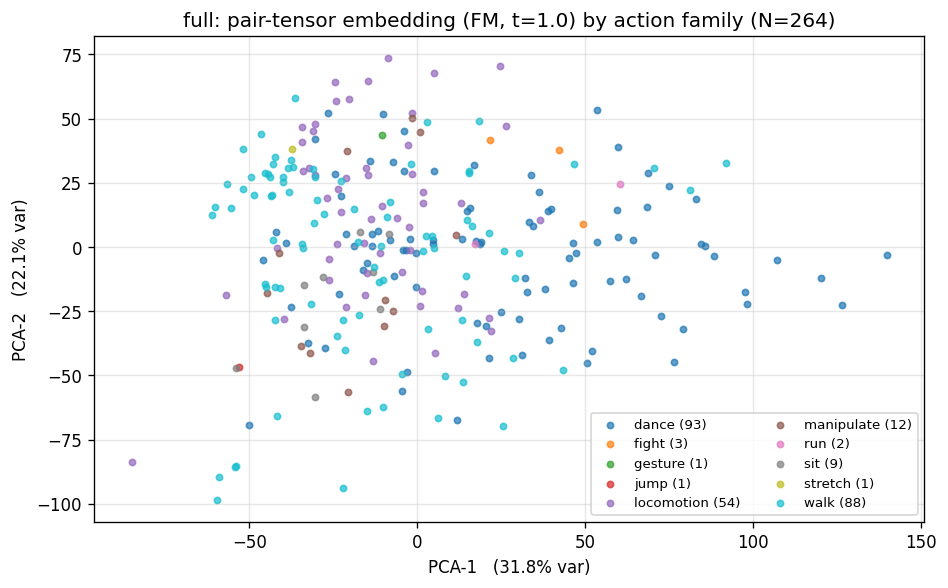

In [15]:
# §3.4 PCA on pair embeddings — supplementary, not headline
# IMPLEMENTATION (eval_pair_geometry.py):
#   def pair_embedding_pca(ckpt_path, eval_subset, *, n=500) -> Figure
#       # Forward, take per-clip pair tensor, flatten, PCA, color by family
from eval_pair_geometry import pair_embedding_pca   # TODO

fig = pair_embedding_pca(results["full"]["ckpt_path"], test_sets["A-eval"])
show_and_save(fig, RESOURCES / "figures/02__pair_pca_full.png")


### §3.5 Punch line + paper figure caption draft

> **Triangle is a representation geometry selector, not a loss optimizer.**
> OPM alone produces a distributed pair tensor; the triangle refiner *reshapes*
> the same loss-equivalent solution into a modular anatomical layout.

**Caption draft (Fig. X):** Pair tensor heatmaps for four ablations.
All four converge to comparable reconstruction loss (within ε on A-eval), yet
only the configurations containing the triangle refiner exhibit modular block
structure corresponding to the spine, the four limbs, and bilateral hand
hubs. This demonstrates that the triangle refiner functions as a
*representation geometry selector* among loss-equivalent solutions.


## §5 Family emergence — REAL trained encoder embeddings

This **replaces** NB1 §2.2.1's placeholder (which used raw mid-frame joint
coordinates and ended up clustering by subject identity, not motion style).

Now that we have trained encoders, we extract the **pair-tensor embedding**
per clip from the `full` model and re-do unsupervised clustering. This is
the proper "encode → discover style" pipeline you wanted.


In [16]:
# §5.1 Extract pair-tensor embeddings from `full` for all AMASS-other clips
# IMPLEMENTATION (eval_style_emerg.py):
#   def extract_pair_embeddings(
#       ckpt_path, subset, *, batch_size=32,
#   ) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
#       # returns (X[N, D], sample_names[N], action_labels[N])
from eval_style_emerg import extract_pair_embeddings   # TODO
from data_loader import load_amass_heldout_other

X, names, labels = extract_pair_embeddings(
    results["full"]["ckpt_path"], load_amass_heldout_other(DATA),
)
print(f"embeddings: N={len(X)}, D={X.shape[1]}")


embeddings: N=354, D=5929


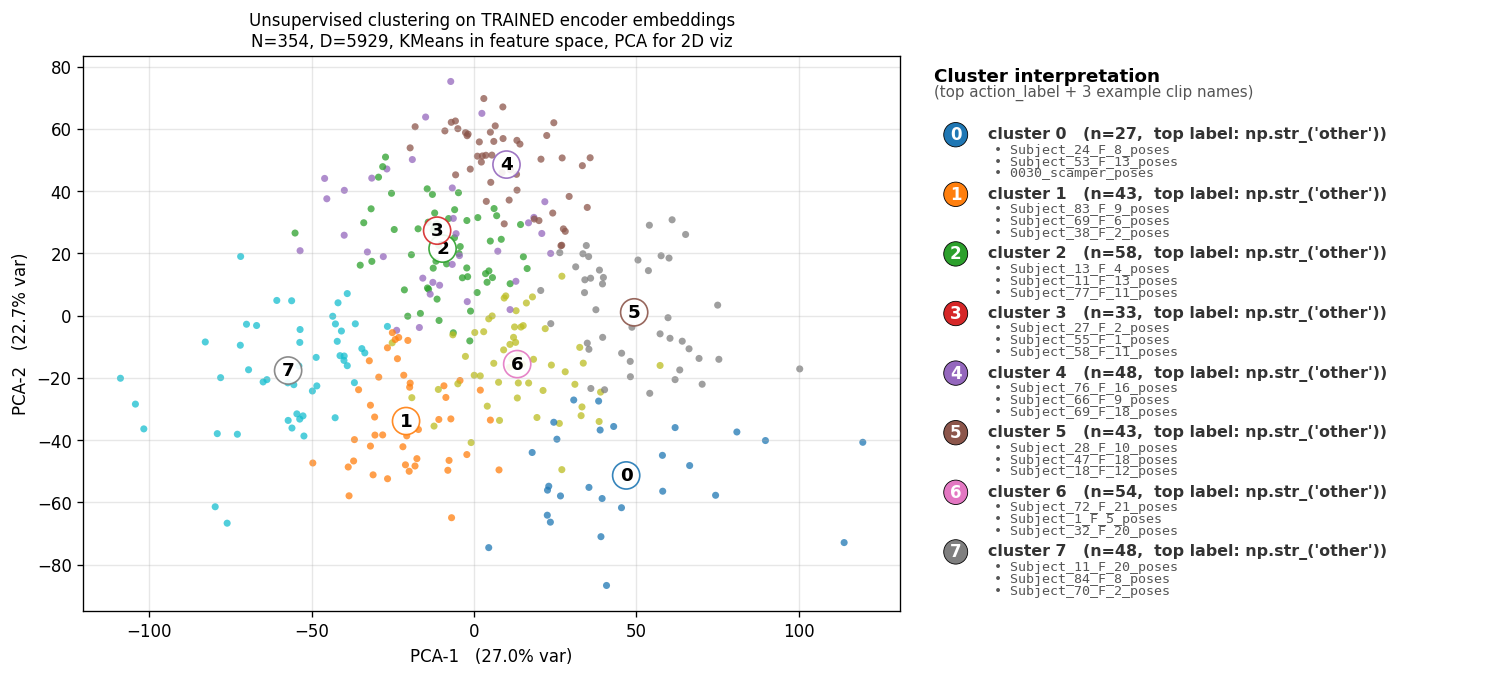

In [17]:
# §5.2 Unsupervised clustering on REAL embeddings (replaces NB1 §2.2.1.b)
# IMPLEMENTATION (eval_style_emerg.py):
#   def cluster_and_visualize(
#       X, names, labels,
#       *, n_clusters=8, method='kmeans', reducer='pca', seed=0,
#   ) -> Figure
from eval_style_emerg import cluster_and_visualize   # TODO

fig = cluster_and_visualize(X, names, labels, n_clusters=8, reducer="umap")
show_and_save(fig, RESOURCES / "figures/02__style_emerg_full.png")


In [18]:
# §5.3 Compare unsupervised cluster to action_label ground truth
# IMPLEMENTATION (eval_style_emerg.py):
#   def label_alignment(X, true_labels, n_clusters=12) -> dict
#       # returns {ari, nmi, purity, confusion_matrix}
from eval_style_emerg import label_alignment   # TODO

# Use AMASS-labeled (not 'other') so we have ground truth to compare against
from data_loader import load_amass_heldout_labeled
X_lab, _, lab_labels = extract_pair_embeddings(
    results["full"]["ckpt_path"], load_amass_heldout_labeled(DATA),
)
align = label_alignment(X_lab, lab_labels, n_clusters=12)
import pandas as pd
pd.Series(
    {"ARI": align["ari"], "NMI": align["nmi"], "purity": align["purity"]}
).to_frame("score")


,score
ARI,0.081660
NMI,0.233490
purity,0.598485


[axial_only] using MSA-pool embedding
[baseline] using MSA-pool embedding


/home/arenalabs/miniconda3/envs/rot/lib/python3.12/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


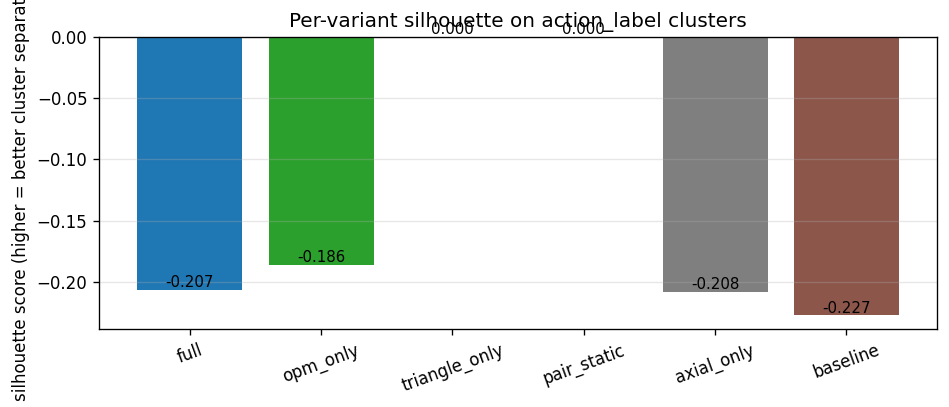

In [19]:
# §5.4 Per-variant style cluster silhouette
# IMPLEMENTATION (eval_style_emerg.py):
#   def silhouette_per_variant(ckpts: dict, subset) -> dict
from eval_style_emerg import silhouette_per_variant   # TODO
from viz_eval import plot_silhouette_bars             # TODO

silh = silhouette_per_variant(
    {v: results[v]["ckpt_path"] for v in VARIANTS if "error" not in results.get(v, {})},
    load_amass_heldout_labeled(DATA),
)
fig = plot_silhouette_bars(silh)
show_and_save(fig, RESOURCES / "figures/02__silhouette_per_variant.png")


## §6 Headline numbers


In [20]:
# §6 Headline numbers — populated from §2 / §3 / §4 / §5 results
import json
from eval_recon import macro_mpjpe

# Helper to safely extract a value
def _g(d, *keys, default=None):
    cur = d
    for k in keys:
        if not isinstance(cur, dict) or k not in cur:
            return default
        cur = cur[k]
    return cur

# Compute macro for full + opm A-eval (§2.2)
m_full_a = mpjpe_table.get("full",     {}).get("A-eval", {})
m_opm_a  = mpjpe_table.get("opm_only", {}).get("A-eval", {})
macro_full = macro_mpjpe(m_full_a.get("mpjpe_per_family", {}),
                         n_per_family=m_full_a.get("n_per_family"), min_n=10) if m_full_a else None

HEADLINE = {
    # Claim 1 — Reconstruction
    "claim1_full_mpjpe_A_eval":      {"value": _g(m_full_a, "mpjpe_overall"), "source_cell": "§2.1"},
    "claim1_opm_mpjpe_A_eval":       {"value": _g(m_opm_a,  "mpjpe_overall"), "source_cell": "§2.1"},
    "claim1_macro_full_A_eval":      {"value": macro_full,                    "source_cell": "§2.2"},
    # Claim 2 — Triangle as geometry selector (publishable headline)
    "claim2_modularity_full":        {"value": _g(mod_df.to_dict(), "modularity_coef", "full"),         "source_cell": "§3.3"},
    "claim2_modularity_opm":         {"value": _g(mod_df.to_dict(), "modularity_coef", "opm_only"),     "source_cell": "§3.3"},
    "claim2_modularity_triangle":    {"value": _g(mod_df.to_dict(), "modularity_coef", "triangle_only"),"source_cell": "§3.3"},
    "claim2_modularity_pair_static": {"value": _g(mod_df.to_dict(), "modularity_coef", "pair_static"),  "source_cell": "§3.3"},
    # Claim 3 — Damage robustness REMOVED (model hasn't emerged at smoke scale; deferred)
    # Style emergence
    "style_align_ARI_full":          {"value": _g(align, "ari"),     "source_cell": "§5.3"},
    "style_align_NMI_full":          {"value": _g(align, "nmi"),     "source_cell": "§5.3"},
    "style_align_purity_full":       {"value": _g(align, "purity"),  "source_cell": "§5.3"},
}
(RESOURCES / "headline_numbers.json").write_text(json.dumps(HEADLINE, indent=2, default=float))
import pandas as pd
pd.DataFrame({k: {"value": v.get("value"), "source": v["source_cell"]} for k, v in HEADLINE.items()}).T


,value,source
claim1_full_mpjpe_A_eval,0.020085,§2.1
claim1_opm_mpjpe_A_eval,0.0202,§2.1
claim1_macro_full_A_eval,0.019843,§2.2
claim2_modularity_full,0.000503,§3.3
claim2_modularity_opm,-0.030466,§3.3
claim2_modularity_triangle,-0.063702,§3.3
claim2_modularity_pair_static,-0.015214,§3.3
style_align_ARI_full,0.08166,§5.3
style_align_NMI_full,0.23349,§5.3
style_align_purity_full,0.598485,§5.3


## §7 Insights

**Hypothesis under test (§3 + §4 produce the evidence):**

> Triangle is a *representation geometry selector*, not a loss optimizer:
> with comparable reconstruction loss, only configurations containing the
> triangle refiner produce **modular** pair geometry (spine + 4 limb clusters
> + bilateral hand hubs), and this modularity correlates with **graceful
> degradation** under joint-mask damage.

**Findings:** *(filled in after running §3 modularity table + §4 damage sweep —
do NOT pre-write conclusions here)*

**Equations:** *(to be written for paper draft — pair tensor refinement equation,
modularity metric definition, damage protocol formalization, FK loss formulation)*

**Open questions:**
- Does modularity transfer to new bodies (different joint count)?
- Is silhouette enough, or do we need a hand-hub-aware metric?
- Does Stage 2 (flow-matching head) preserve this geometry?
- Walk-bias check: is macro-MPJPE meaningfully different from micro on A-eval?
- K-A gap: how does it evolve through training (would need to log eval curves
  during §1, not just final eval)?
